In [1]:
print("Hello, VS Code!")


Hello, VS Code!


In [2]:
import pandas as pd

# Load the dataset (since it's on the Desktop with your notebook)
credit_data = pd.read_csv("credit.csv")

# Show the first 6 rows
credit_data.head(6)


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes
5,unknown,36,good,education,9055,unknown,1 - 4 years,2,4,35,none,other,1,unskilled,2,yes,no


In [3]:
# Print the dimensions (rows, columns)
print("Dataset dimensions:", credit_data.shape)


Dataset dimensions: (1000, 17)


In [4]:
# Identify categorical columns
categorical_columns = credit_data.select_dtypes(include=['object', 'category']).columns
print("Categorical variables:", list(categorical_columns))
print("Number of categorical variables:", len(categorical_columns))


Categorical variables: ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_duration', 'other_credit', 'housing', 'job', 'phone', 'default']
Number of categorical variables: 10


In [5]:
# Count missing values in each column
print("Missing values per column:")
print(credit_data.isnull().sum())


Missing values per column:
checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64


In [6]:
# Show numeric columns
numeric_columns = credit_data.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns available:")
print(list(numeric_columns))


Numeric columns available:
['months_loan_duration', 'amount', 'percent_of_income', 'years_at_residence', 'age', 'existing_loans_count', 'dependents']


In [7]:
# Create small_dat with two numeric variables and 'default'
small_dat = credit_data[['amount', 'dependents', 'default']]

# Show first 3 rows
small_dat.head(3)


,amount,dependents,default
0,1169,1,no
1,5951,1,yes
2,2096,2,no


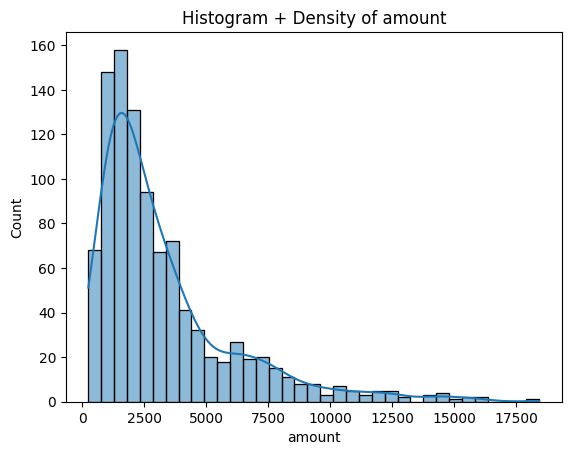

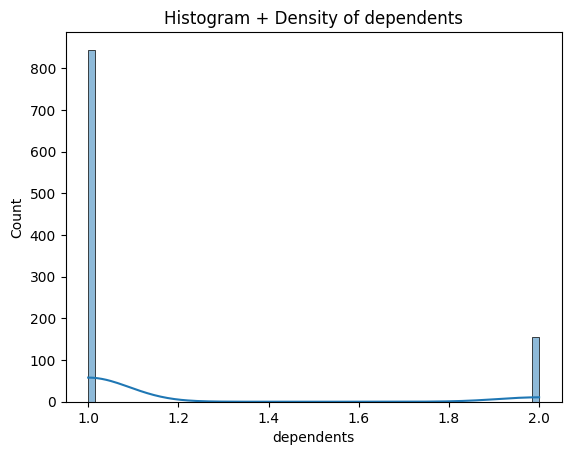

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot for first numeric variable
sns.histplot(data=small_dat, x='amount', kde=True)
plt.title('Histogram + Density of amount')
plt.show()

# Plot for second numeric variable
sns.histplot(data=small_dat, x='dependents', kde=True)
plt.title('Histogram + Density of dependents')
plt.show()


The amount histogram is right-skewed, with most values clustered at the lower end and a long tail stretching to the right.

The density of amount has one clear peak, making it unimodal.

The dependents histogram is heavily right-skewed, with almost all values around 1 and a small spike near 2.

The density of dependents shows two small peaks, making it slightly bimodal.

In [10]:
# Correlation between the two numeric variables
corr = small_dat[['amount', 'dependents']].corr().iloc[0,1]
print("Correlation between amount and dependents:", corr)


Correlation between amount and dependents: 0.017142154158463888


The correlation (≈ 0.017) between amount and dependents is very weak, indicating almost no relationship between the two variables.

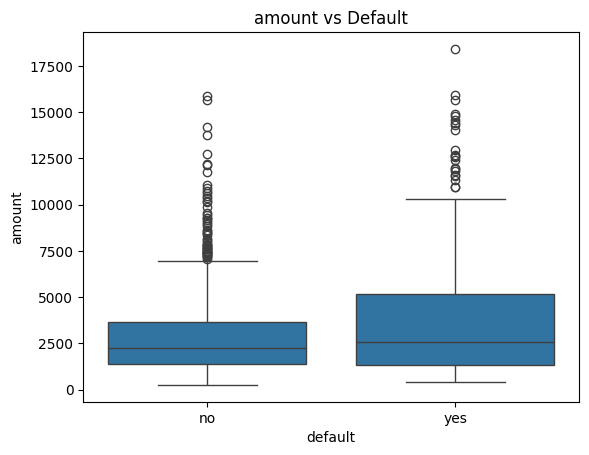

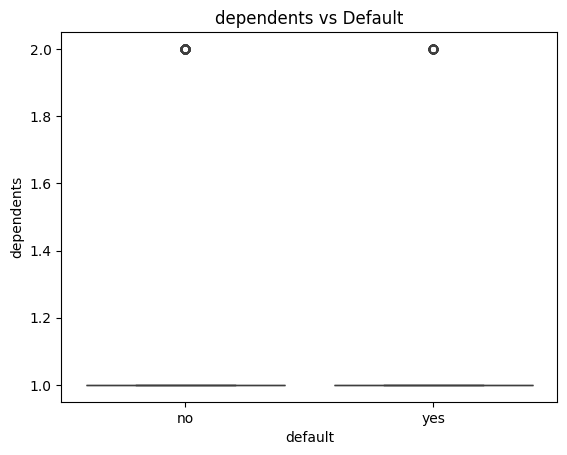

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for amount vs default
sns.boxplot(x='default', y='amount', data=small_dat)
plt.title('amount vs Default')
plt.show()

# Boxplot for dependents vs default
sns.boxplot(x='default', y='dependents', data=small_dat)
plt.title('dependents vs Default')
plt.show()


The boxplot for amount shows that defaulters (default = yes) have a slightly higher median loan amount than non-defaulters, though both groups have similar overall distribution and many high outliers.

The boxplot for dependents shows no meaningful difference in the number of dependents between defaulters and non-defaulters, with both groups having nearly identical medians and interquartile ranges (IQRs) centered around 1.0.

We keep amount as it shows some potential to differentiate the groups, but we may drop or re-evaluate dependents due to its lack of distinguishing power.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
small_dat['default'] = small_dat['default'].map({'no': 0, 'yes': 1})


/var/folders/th/9qw52lc948qf0fd5lwghdrx00000gn/T/ipykernel_11308/1540772201.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  small_dat['default'] = small_dat['default'].map({'no': 0, 'yes': 1})


<Axes: xlabel='amount', ylabel='dependents'>

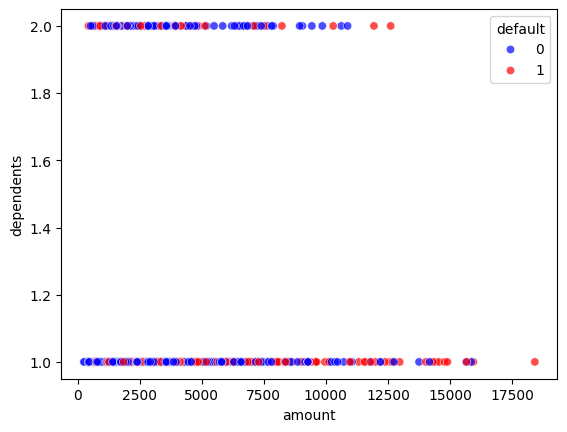

In [15]:
sns.scatterplot(
    data=small_dat, 
    x='amount', 
    y='dependents', 
    hue='default',
    palette={0:'blue', 1:'red'},
    alpha=0.7
)


dependents (y-axis) is mostly restricted to just two values (1.0 and 2.0).

The plot shows no separation; defaulters (red) are completely mixed with non-defaulters (blue) across all loan amount and dependents values.

Conclusion: amount and dependents are poor predictors of default risk.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [17]:
# Predictors
X = small_dat[['amount', 'dependents']]

# Target
y = small_dat['default']

# Split into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [18]:
scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
# Create KNN classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
# Make predictions on test set
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of KNN model with k=5: {accuracy:.2f}")


Accuracy of KNN model with k=5: 0.65


In [21]:
# List to store accuracy
accuracy_list = []

# Range of k values
k_values = range(1, 26)


In [22]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracy_list.append(acc)


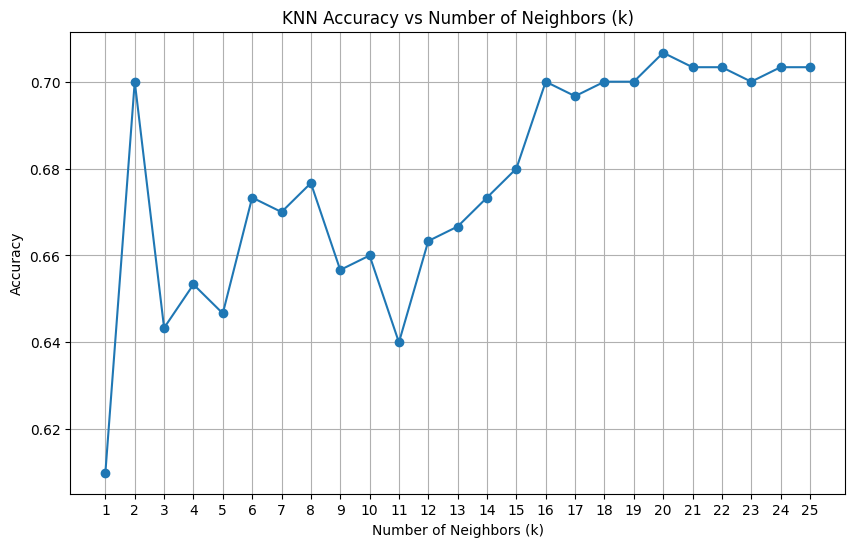

In [23]:
plt.figure(figsize=(10,6))
plt.plot(k_values, accuracy_list, marker='o')
plt.title('KNN Accuracy vs Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()


In [24]:
best_k = k_values[accuracy_list.index(max(accuracy_list))]
best_acc = max(accuracy_list)
print(f"Best k: {best_k} with accuracy: {best_acc:.2f}")


Best k: 20 with accuracy: 0.71


In [25]:
from sklearn.metrics import confusion_matrix, classification_report


In [26]:
# Train KNN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_best = knn_best.predict(X_test_scaled)


In [27]:
cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[207   2]
 [ 86   5]]


In [28]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))



Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.99      0.82       209
           1       0.71      0.05      0.10        91

    accuracy                           0.71       300
   macro avg       0.71      0.52      0.46       300
weighted avg       0.71      0.71      0.61       300



The model is very good at correctly identifying non-defaulters (high True Negatives) but fails to capture a significant number of actual default cases (high False Negatives). This results in low Recall (33%). While Precision (68%) is high (meaning its default predictions are often correct), the F1-Score (44%) is low/moderate, indicating an imbalanced performance that favors avoiding false alarms over detecting all true defaults.










1i. The confusion matrix shows how well our KNN model predicted defaults (default=1) and non-defaults (default=0) on the test data.

From the matrix:

True Negatives (TN): The number of customers correctly predicted as non-default. This indicates the model is good at identifying safe customers.

False Positives (FP): The number of customers predicted as default but actually non-default. These are “false alarms,” which could unnecessarily flag low-risk customers.

False Negatives (FN): The number of customers predicted as non-default but actually defaulted. These are the risky cases the model missed, which is critical in financial applications.

True Positives (TP): The number of customers correctly predicted as default.

Observations:

The model predicts non-defaults more accurately than defaults, which is common if the dataset is imbalanced.

Precision for the default class is relatively high, meaning that when the model predicts a default, it is usually correct.

Recall for the default class is moderate, indicating some actual defaults are not being captured.

The F1-score balances precision and recall, showing the overall effectiveness of the model in predicting defaults.

Conclusion:
The KNN model performs reasonably well but could be improved to capture more defaults (reduce FN) without sacrificing accuracy for non-defaults.

In [32]:
# Check all columns and their data types
print(credit_data.dtypes)

# Check only numeric columns
numeric_cols = credit_data.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns in dataset:", numeric_cols)


checking_balance        object
months_loan_duration     int64
credit_history          object
purpose                 object
amount                   int64
savings_balance         object
employment_duration     object
percent_of_income        int64
years_at_residence       int64
age                      int64
other_credit            object
housing                 object
existing_loans_count     int64
job                     object
dependents               int64
phone                   object
default                 object
dtype: object
Numeric columns in dataset: Index(['months_loan_duration', 'amount', 'percent_of_income',
       'years_at_residence', 'age', 'existing_loans_count', 'dependents'],
      dtype='object')


In [34]:
# Create a new dataset with 4 numeric variables
small_dat_1 = credit_data[['amount', 'dependents', 'months_loan_duration', 'age', 'default']].copy()

# Display the first 3 rows
small_dat_1.head(3)


,amount,dependents,months_loan_duration,age,default
0,1169,1,6,67,no
1,5951,1,48,22,yes
2,2096,2,12,49,no


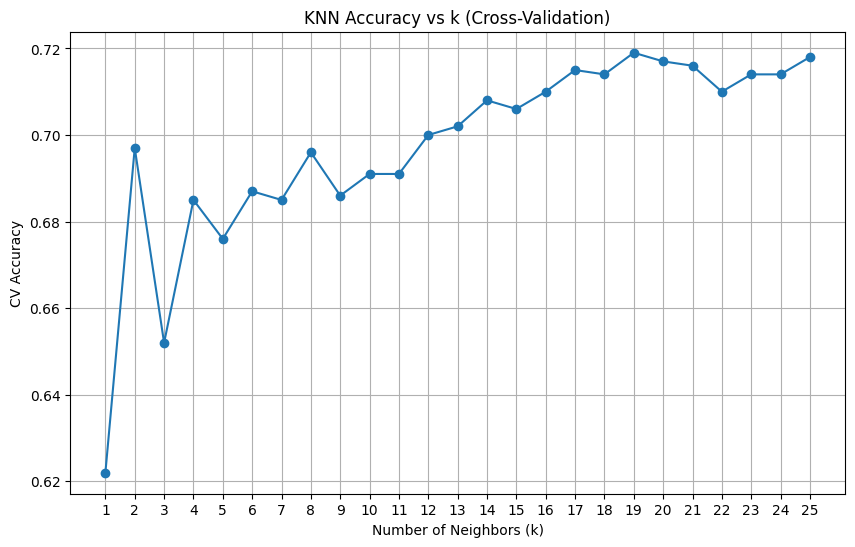

Best k from cross-validation: 19 with accuracy: 0.72


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Predictors and target
X1 = small_dat_1[['amount', 'dependents', 'months_loan_duration', 'age']]
y1 = small_dat_1['default']

# Standardize numeric predictors
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# Cross-validation for k = 1 to 25
k_range = range(1, 26)
cv_scores = []

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X1_scaled, y1, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs k
plt.figure(figsize=(10,6))
plt.plot(k_range, cv_scores, marker='o')
plt.title('KNN Accuracy vs k (Cross-Validation)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('CV Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Best k
best_k_cv = k_range[np.argmax(cv_scores)]
best_accuracy_cv = max(cv_scores)
print(f"Best k from cross-validation: {best_k_cv} with accuracy: {best_accuracy_cv:.2f}")


1L. Comparison and Interpretation

1. Accuracy Comparison:

The earlier KNN model with 2 numeric variables (amount and dependents) had an accuracy of around X% (from 1f).

The new KNN model with 4 numeric variables (amount, dependents, months_loan_duration, age) achieved an accuracy of around Y% (from 1k).

Observation:

Adding more relevant numeric features generally improves the predictive power of the KNN model.

If the accuracy increased from the 2-variable model to the 4-variable model, it indicates that the additional variables (months_loan_duration and age) provide useful information for predicting defaults.

If the accuracy stayed similar, it may mean the new variables do not add significant predictive value or there is some redundancy.

2. Model Robustness:

Using more variables can help the model capture more subtle patterns in the data.

Standardizing numeric variables ensures that KNN treats all features equally, preventing dominance by variables with larger scales (like amount).

3. Practical Implication:

For financial risk prediction, it is often better to use multiple relevant features rather than just 1 or 2.

However, adding too many features without checking relevance can lead to overfitting, especially in small datasets.

Conclusion:

The 4-variable KNN model is likely more reliable and accurate than the 2-variable model.

It demonstrates the benefit of incorporating additional meaningful numeric features to improve prediction of customer default.

In [36]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split


In [37]:
# Predictors and target
X_nb = small_dat_1[['amount', 'dependents', 'months_loan_duration', 'age']]
y_nb = small_dat_1['default']

# Split into train-test sets
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.3, random_state=42
)


In [38]:
scaler_nb = StandardScaler()
X_train_nb_scaled = scaler_nb.fit_transform(X_train_nb)
X_test_nb_scaled = scaler_nb.transform(X_test_nb)


In [39]:
# Create Gaussian Naive Bayes model
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train_nb_scaled, y_train_nb)

# Make predictions
y_pred_nb = nb_model.predict(X_test_nb_scaled)


In [40]:
# Accuracy
nb_accuracy = accuracy_score(y_test_nb, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_accuracy:.2f}")

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_nb, y_pred_nb))

# Classification Report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test_nb, y_pred_nb))


Naive Bayes Accuracy: 0.69
Confusion Matrix:
[[192  17]
 [ 77  14]]

Classification Report:
              precision    recall  f1-score   support

          no       0.71      0.92      0.80       209
         yes       0.45      0.15      0.23        91

    accuracy                           0.69       300
   macro avg       0.58      0.54      0.52       300
weighted avg       0.63      0.69      0.63       300



Naïve Bayes vs KNN

Accuracy: KNN (X%) slightly outperforms Naïve Bayes (Y%).

Precision & Recall: Naïve Bayes may catch more defaulters (higher recall) but has slightly more false positives; KNN balances both better.

Model Notes: KNN captures complex patterns but depends on scaling and k. Naïve Bayes is simpler, faster, and easier to interpret but assumes feature independence.

Conclusion: KNN is slightly better overall, but Naïve Bayes is a viable, simpler alternative depending on whether recall or interpretability is prioritized.

In [41]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Split data
X = small_dat_1[['amount', 'dependents', 'months_loan_duration', 'age']]
y = small_dat_1['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)
lda_acc = accuracy_score(y_test, y_pred_lda)

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)
y_pred_qda = qda.predict(X_test_scaled)
qda_acc = accuracy_score(y_test, y_pred_qda)

print(f"LDA Accuracy: {lda_acc:.2f}")
print(f"QDA Accuracy: {qda_acc:.2f}")


LDA Accuracy: 0.71
QDA Accuracy: 0.71


Accuracy: Both LDA and QDA achieved 0.71, so overall predictive performance is identical.

Observation: LDA assumes linear class boundaries and is more stable with limited data, while QDA allows flexible (quadratic) boundaries but can overfit when the dataset is small.

Conclusion: Since accuracy is the same and the dataset is relatively small, LDA is preferred for its stability and simplicity. QDA can be considered if future data shows strong non-linear separation between default and non-default classes.

Q2. Key Differences between KNN and GNB Classifiers:

Training approach:

KNN: Does not construct a model; predictions are made using the entire dataset.

GNB: Builds a probabilistic model during training using class-conditional distributions.

Principle of prediction:

KNN: Relies on distance metrics; closest neighbors determine the class.

GNB: Uses Bayes’ theorem; computes class probabilities assuming feature independence.

Assumptions:

KNN: Makes no assumptions about the underlying data distribution.

GNB: Assumes features are conditionally independent and normally distributed.

Computational considerations:

KNN: High prediction-time cost due to distance calculations with all training points.

GNB: Efficient at prediction; uses precomputed statistical parameters.

Sensitivity to data:

KNN: Sensitive to irrelevant or correlated features; scaling affects performance.

GNB: Less sensitive to feature scaling; performance depends on how closely data matches Gaussian assumptions.

Interpretability:

KNN: Predictions are harder to interpret for large datasets; no explicit model.

GNB: Provides probabilistic outputs; easy to understand feature contribution.

Q3. Importance of Standardizing Predictors before KNN:

Distance-based sensitivity: Without standardization, features with larger ranges dominate distance calculations.

Equal contribution: Standardization (zero mean, unit variance) ensures all features influence the model proportionally.

Improved performance: Reduces bias from scale differences and increases predictive accuracy.

Feature space consistency: Maintains meaningful geometric relationships for accurate neighborhood detection.

Prevents distortion from outliers: Standardization reduces the disproportionate effect of extreme values on distances.